In [29]:
import pandas as pd
import os
import cv2
import matplotlib.pyplot as plt
import random

labels_file = './english.csv'

In [23]:
csv = pd.read_csv(labels_file)
img_files = csv.to_dict()['image']
labels = csv.to_dict()['label']

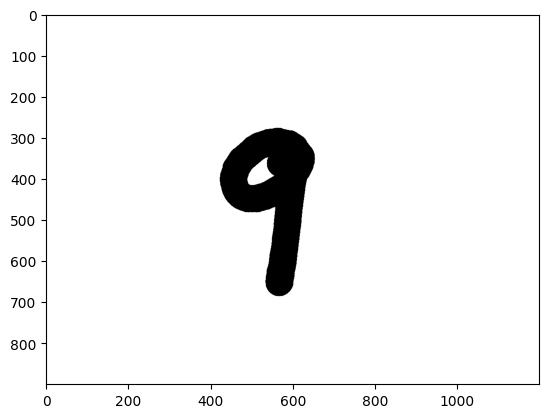

In [25]:
im1 = cv2.imread(img_files[500], cv2.IMREAD_GRAYSCALE)
plt.imshow(im1/255, cmap='gray')

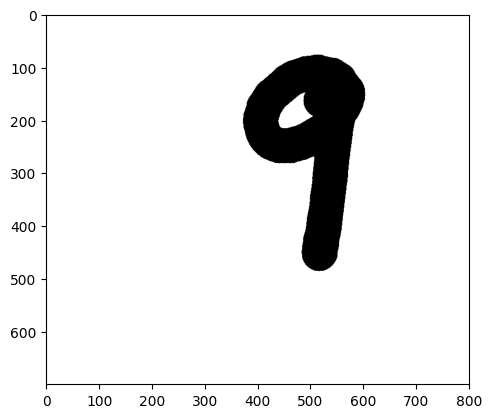

In [26]:
cropped = im1[200:10001, 50:851]
plt.imshow(cropped/255, cmap='gray')

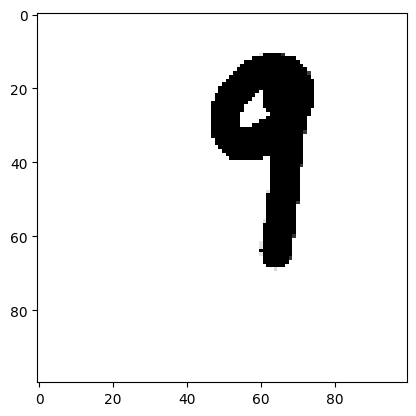

In [27]:
cropped = cv2.resize(cropped, (100, 100))
plt.imshow(cropped/255, cmap='gray')

['Img/img001-001.png',
 'Img/img001-002.png',
 'Img/img001-003.png',
 'Img/img001-004.png',
 'Img/img001-005.png',
 'Img/img001-006.png',
 'Img/img001-007.png',
 'Img/img001-008.png',
 'Img/img001-009.png',
 'Img/img001-010.png']

In [ ]:
test_train_split = 0.8

img_labels = {img_files[i]: labels[i] for i in range(len(img_files))}
shuffled_imgs = list(img_labels.keys())
random.shuffle(shuffled_imgs)
train_size = int(len(img_labels) * test_train_split)
test_size = len(img_labels) - train_size

train_imgs = shuffled_imgs[:train_size]
test_imgs = shuffled_imgs[train_size:]

os.mkdir('train')
os.mkdir('test')
os.mkdir('test/Img')
os.mkdir('train/Img')

for img in train_imgs:
    os.rename(img, os.path.join('train', img))

for img in test_imgs:
    os.rename(img, os.path.join('test', img))

KeyError: 'Img/img030-033.png'

In [43]:
with open('train_labels.txt', 'w') as f:
    for img in train_imgs:
        f.write(f"{img},{img_labels[img]}\n")

with open('test_labels.txt', 'w') as f:
    for img in test_imgs:
        f.write(f"{img},{img_labels[img]}\n")